### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import re
from bs4 import BeautifulSoup
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [116]:
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [37]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModel

In [6]:
import torchinfo
import torchviz

In [7]:
import time

In [8]:
import torch
from torch import nn, utils, optim

### Step 2: Constant

In [90]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAIN_PATH = './data/aclImdb/train/'
TEST_PATH = './data/aclImdb/test/'
LABEL_LIST = ['neg', 'pos']
MODEL_NAME = 'bert-base-uncased'
PADDING_LEN = 128
BATCH_SIZE = 128
INIT_LR = 0.001
EPOCHS = 20
LEARNING_RATE = 2e-5

### Step 3: Load Data

In [10]:
def get_df(fold_path):
    sentence_list, sentiment_list = list(), list()
    for i in range(len(LABEL_LIST)):
        file_list = os.listdir(f'{fold_path}{LABEL_LIST[i]}')
        for j, file in enumerate(file_list):
            with open(f'{fold_path}{LABEL_LIST[i]}/{file}', encoding='utf-8') as f:
                sentence_list.append(f.read())
                sentiment_list.append(i)
            print(f'\r{j+1}/{len(file_list)}', end='')
    return pd.DataFrame(
        {
            'sentence': sentence_list,
            'sentiment': sentiment_list
        }
    )

In [11]:
train = get_df(TRAIN_PATH)

12500/12500

In [12]:
test = get_df(TEST_PATH)

12500/12500

In [13]:
train.shape

(25000, 2)

In [14]:
train.head()

,sentence,sentiment
0,Story of a man who has unnatural feelings for ...,0
1,Airport '77 starts as a brand new luxury 747 p...,0
2,This film lacked something I couldn't put my f...,0
3,"Sorry everyone,,, I know this is supposed to b...",0
4,When I was little my parents took me along to ...,0


### Step 4: Exploaring Data

#### Feature Distribution

In [15]:
temp = train['sentiment'].value_counts()

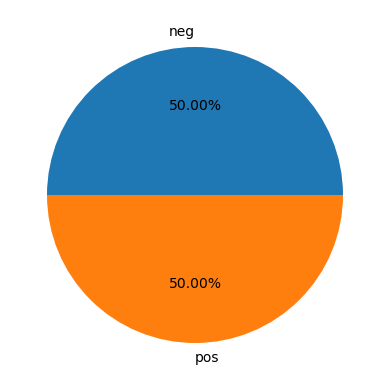

In [16]:
plt.figure(figsize=(4, 4))
plt.pie(
    temp,
    autopct='%.2f%%',
    labels=LABEL_LIST
)
plt.tight_layout()

### Step 5: Preparing Data

#### Text Cleaning

In [17]:
def text_cleaning(text):
    soup = BeautifulSoup(text, "html.parser")
    text = re.sub(r'\[[^]]*\]', '', soup.get_text())
    pattern = r"[^a-zA-Z0-9\s,']"
    text = re.sub(pattern, '', text)
    return text

In [18]:
train['sentence'] = train['sentence'].map(text_cleaning).str.lower()
test['sentence'] = test['sentence'].map(text_cleaning).str.lower()

#### Punctuations Removal

In [19]:
def remove_punctuations(text):
    temp = str.maketrans('', '', string.punctuation)
    return text.translate(temp)

In [20]:
train['sentence'] = train['sentence'].map(remove_punctuations)
test['sentence'] = test['sentence'].map(remove_punctuations)

#### Stopwords Removal and Lemmatization

In [21]:
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words]
    return ' '.join(words)

In [22]:
train['sentence'] = train['sentence'].map(preprocess_text)
test['sentence'] = test['sentence'].map(preprocess_text)

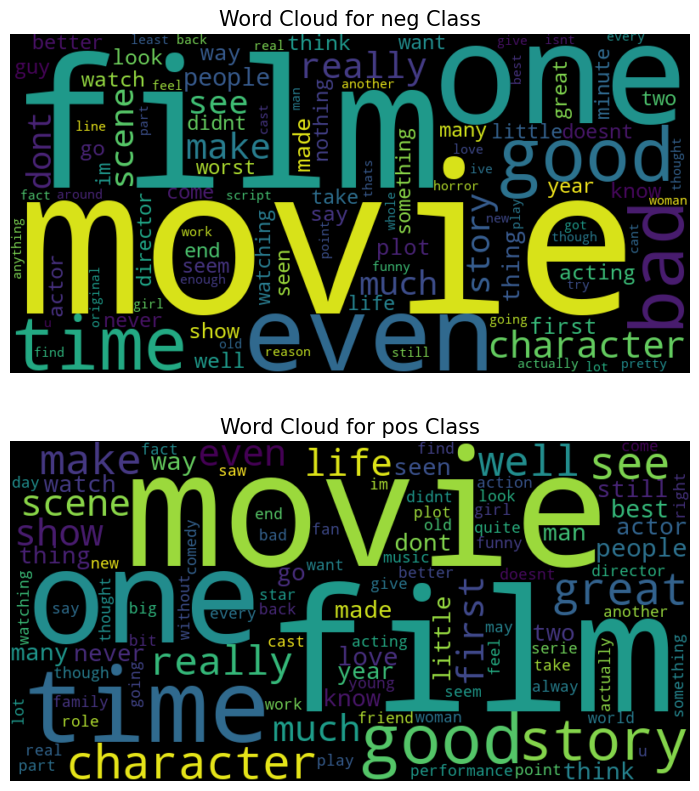

In [23]:
plt.figure(figsize=(10, 15))
for i in range(len(LABEL_LIST)):
    temp = train[train['sentiment']==i]
    corpus = " ".join(temp['sentence'])
    wc = WordCloud(
        max_words=100, 
        width=800, 
        height=400,
        collocations=False
    ).generate(corpus)
    plt.subplot(3, 1, i+1)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for {LABEL_LIST[i]} Class", fontsize=15)

#### Split Data

In [24]:
value, test = train_test_split(
    test,
    test_size=0.5,
    random_state=42,
    stratify=test['sentiment']
)

#### Tokenization and Padding

In [91]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, do_lower_case=True)

In [92]:
def tokenizing(X):
    tokens = tokenizer(
        X,
        max_length=PADDING_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
        return_attention_mask=True
    )
    seqs = tokens['input_ids'][0]
    masks = tokens['attention_mask'][0]
    return seqs, masks

#### Build Generator

In [93]:
class dataset(utils.data.Dataset):
    def __init__(self, df, num):
        super().__init__()
        self.num = num
        self.df = df.sample(num).reset_index(drop=True)
    def __len__(self):
        return min(len(self.df), self.num)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        seq, mask = tokenizing(row['sentence'])
        return {
            'input_ids': torch.tensor(seq, dtype=torch.long),
            'attention_mask': torch.tensor(mask, dtype=torch.long),
            'labels': torch.tensor(row['sentiment'], dtype=torch.long)
        }

In [94]:
train_dataset = dataset(train, 6000)
value_dataset = dataset(value, 2000)
test_dataset = dataset(test, 2000)

In [95]:
train_dataloader = utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)
value_dataloader = utils.data.DataLoader(
    value_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_dataloader = utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [96]:
batch = next(iter(train_dataloader))
print(
    batch['input_ids'].shape,
    batch['attention_mask'].shape,
    batch['labels'].shape
)

torch.Size([128, 128]) torch.Size([128, 128]) torch.Size([128])


### Step 6: Model Development

#### Build Model

In [97]:
bert = AutoModel.from_pretrained(MODEL_NAME)

In [99]:
_ = bert.requires_grad_(False)

In [170]:
class BERT_architecture(nn.Module):
    def __init__(self, bert, n_label):
        super().__init__()
        self.bert = bert
        self.dropout = nn.Dropout(0.1)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(768, 512)
        self.fc2 = nn.Linear(512, n_label)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, seq, mask):
        _, cls_hs = self.bert(seq, attention_mask=mask, return_dict=False)
        x = self.fc1(cls_hs)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.softmax(x)
        return x

In [101]:
model = BERT_architecture(bert, len(LABEL_LIST))

In [102]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

fc1.weight
fc1.bias
fc2.weight
fc2.bias


In [78]:
torchinfo.summary(
    model,
    input_data={
        'seq': torch.randint(0, 1000, (128, 128)),
        'mask': torch.randint(0, 2, (128, 128))
    }
)

Layer (type:depth-idx)                                       Output Shape              Param #
BERT_architecture                                            [128, 2]                  --
├─BertModel: 1-1                                             [128, 128, 768]           --
│    └─BertEmbeddings: 2-1                                   [128, 128, 768]           --
│    │    └─Embedding: 3-1                                   [128, 128, 768]           (23,440,896)
│    │    └─Embedding: 3-2                                   [128, 128, 768]           (1,536)
│    │    └─Embedding: 3-3                                   [1, 128, 768]             (393,216)
│    │    └─LayerNorm: 3-4                                   [128, 128, 768]           (1,536)
│    │    └─Dropout: 3-5                                     [128, 128, 768]           --
│    └─BertEncoder: 2-2                                      [128, 128, 768]           --
│    │    └─ModuleList: 3-6                                  --     

In [58]:
outputs = model(
    seq=torch.randint(0, 1000, (128, 128)),
    mask=torch.randint(0, 2, (128, 128))
)

In [61]:
dot = torchviz.make_dot(outputs, params=dict(model.named_parameters()))

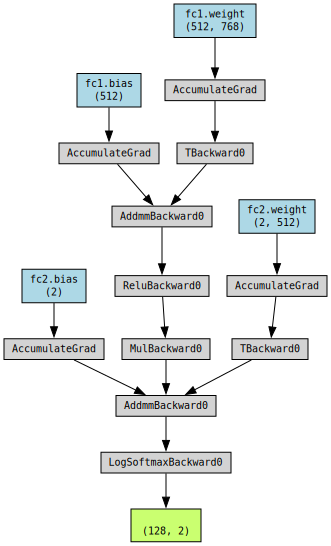

In [62]:
dot

In [42]:
dot.render("bert_model", format="png")

'bert_model.png'

#### Compile Model

In [103]:
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [104]:
loss_fn = nn.NLLLoss()

In [105]:
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=5,
    verbose=False
)

#### Train Model

In [106]:
def run(model, dataloader, loss_fn, optimizer=None, device='cpu', is_train=True, out_preds=False):
    if is_train:
        model.train()
    else:
        model.eval()

    total_loss, total_acc = 0, 0
    total_num = 0
    if out_preds:
        total_preds = list()

    for batch in dataloader:
        batch = [batch[key].to(device) for key in batch.keys()]
        seqs, masks, labels = batch

        if is_train:
            if optimizer is None:
                raise NotImplementedError('if is train, optimizer shoud be have')
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            preds = model(seq=seqs, mask=masks)
            loss =loss_fn(preds, labels)

            if is_train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        total_loss += loss.item() * seqs.size(0)
        preds = torch.argmax(preds, dim=1)
        total_acc += (preds == labels).sum().item()
        total_num += seqs.size(0)
        if out_preds:
            total_preds.append(preds.detach().cpu())

    avg_loss = total_loss / total_num
    avg_acc = total_acc / total_num
    if out_preds:
        total_preds = torch.cat(total_preds, dim=0)
        return avg_loss, avg_acc, total_preds
    return avg_loss, avg_acc

In [107]:
def train_model(model, train_loader, val_loader, loss_fn, optimizer, scheduler=None, num_epochs=5, device='cpu', patience=10):
    best_val_acc = 0.0
    no_improve_count = 0
    best_model_state = model.state_dict()
    history = {
        'loss': list(),
        'val_loss': list(),
        'acc': list(),
        'val_acc': list()
    }
    for epoch in range(1, num_epochs+1):
        print(f'Epoch {epoch}/{num_epochs}')
        print('-' * 30)
        
        # training
        train_loss, train_acc = run(model, train_loader, loss_fn, optimizer, device, is_train=True)
        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}', end=' ')
        history['loss'].append(train_loss)
        history['acc'].append(train_acc)
        
        # valiation
        val_loss, val_acc = run(model, val_loader, loss_fn, device=device, is_train=False)
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # adjust learning rate
        if scheduler is not None:
            scheduler.step(val_loss)

        # save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve_count = 0
        else:
            no_improve_count += 1

        # early stopping
        if no_improve_count >= patience:
            print(f'EarlyStopping triggered. No improvement in {patience} epochs.')
            break

    # load best model
    print(f'\nTraining Complete. Best Val Acc: {best_val_acc:.4f}')
    model.load_state_dict(best_model_state)
    return history

In [108]:
history = train_model(model, train_dataloader, value_dataloader, loss_fn, optimizer, lr_scheduler, num_epochs=EPOCHS, device=DEVICE, patience=10)

Epoch 1/20
------------------------------
Train Loss: 0.6905, Train Acc: 0.5265 Val Loss: 0.6879, Val Acc: 0.5455
Epoch 2/20
------------------------------
Train Loss: 0.6862, Train Acc: 0.5533 Val Loss: 0.6838, Val Acc: 0.5580
Epoch 3/20
------------------------------
Train Loss: 0.6817, Train Acc: 0.5783 Val Loss: 0.6783, Val Acc: 0.5915
Epoch 4/20
------------------------------
Train Loss: 0.6780, Train Acc: 0.5965 Val Loss: 0.6738, Val Acc: 0.6155
Epoch 5/20
------------------------------
Train Loss: 0.6730, Train Acc: 0.6093 Val Loss: 0.6692, Val Acc: 0.6330
Epoch 6/20
------------------------------
Train Loss: 0.6715, Train Acc: 0.6117 Val Loss: 0.6649, Val Acc: 0.6785
Epoch 7/20
------------------------------
Train Loss: 0.6654, Train Acc: 0.6408 Val Loss: 0.6607, Val Acc: 0.6620
Epoch 8/20
------------------------------
Train Loss: 0.6628, Train Acc: 0.6320 Val Loss: 0.6578, Val Acc: 0.6370
Epoch 9/20
------------------------------
Train Loss: 0.6594, Train Acc: 0.6450 Val Loss

In [109]:
train_color = "#2c3e50"
val_color = "#e74c3c"

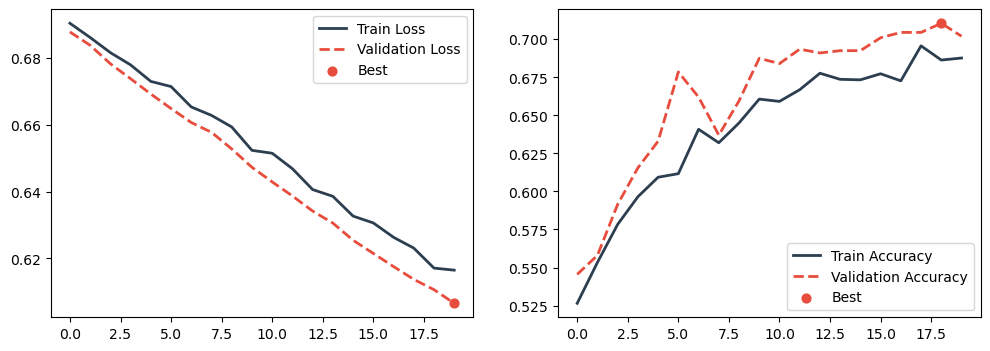

In [110]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.lineplot(history['loss'], label='Train Loss', color=train_color, linewidth=2)
sns.lineplot(history['val_loss'], label='Validation Loss', color=val_color, linewidth=2, linestyle='--')
best_epoch = history['val_loss'].index(min(history['val_loss']))
plt.scatter(best_epoch, history['val_loss'][best_epoch], s=40, label='Best', color=val_color)
plt.legend()
plt.subplot(1, 2, 2)
sns.lineplot(history['acc'], label='Train Accuracy', color=train_color, linewidth=2)
sns.lineplot(history['val_acc'], label='Validation Accuracy', color=val_color, linewidth=2, linestyle='--')
best_epoch = history['val_acc'].index(max(history['val_acc']))
plt.scatter(best_epoch, history['val_acc'][best_epoch], s=40, label='Best', color=val_color)
plt.legend()

#### Evaluate Model

In [113]:
loss, acc, pred = run(model, test_dataloader, loss_fn, device='cpu', is_train=False, out_preds=True)

In [114]:
print(f"Test Accuracy: {acc:.2f}, Test Loss: {loss:.2f}")

Test Accuracy: 0.72, Test Loss: 0.61


In [133]:
test_labels = list()
for temp in iter(test_dataloader):
    test_labels.append(temp['labels'])
test_labels = torch.cat(test_labels)

In [134]:
confusion_matrix = metrics.confusion_matrix(test_labels, pred)

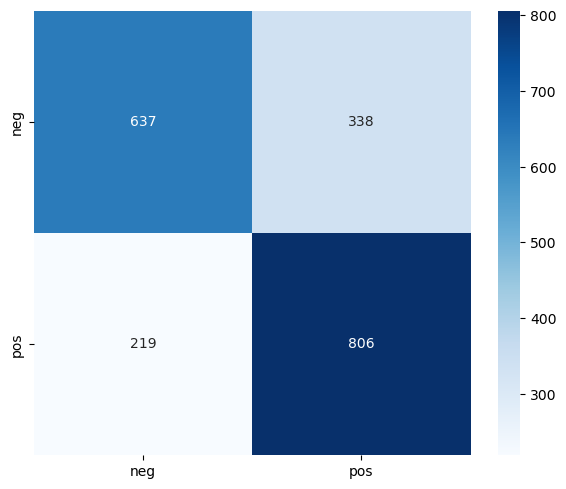

In [138]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt='d',
    cmap=plt.cm.Blues,
    xticklabels=LABEL_LIST,
    yticklabels=LABEL_LIST
)
plt.tight_layout()

In [140]:
print(metrics.classification_report(test_labels, pred))

              precision    recall  f1-score   support

           0       0.74      0.65      0.70       975
           1       0.70      0.79      0.74      1025

    accuracy                           0.72      2000
   macro avg       0.72      0.72      0.72      2000
weighted avg       0.72      0.72      0.72      2000



### Step 7: Prediction

In [177]:
def get_sentiment(review, model=model):
    # Convert Review to a list if it's not already a list
    if not isinstance(review, list):
        review = [review]
    input_ids, attention_mask = tokenizing(review)
    input_ids = input_ids.unsqueeze(0)
    attention_mask = attention_mask.unsqueeze(0)

    prediction = model(seq=input_ids, mask=attention_mask)

    # Use argmax along the appropriate axis to get the predicted labels
    pred_labels = torch.argmax(prediction, axis=1)

    # Convert the TensorFlow tensor to a NumPy array and then to a list to get the predicted sentiment labels
    pred_labels = [LABEL_LIST[i] for i in pred_labels.numpy().tolist()]
    return pred_labels

In [178]:
review = '''Bahubali is a blockbuster Indian movie that was released in 2015. 
It is the first part of a two-part epic saga that tells the story of a legendary hero who fights for his kingdom and his love. 
The movie has received rave reviews from critics and audiences alike for its stunning visuals, 
spectacular action scenes, and captivating storyline.'''

In [179]:
get_sentiment(review)

['pos']